In [3]:
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/utilities.py
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/X.npy
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/y.npy
from utilities import *

--2026-03-10 21:19:55--  https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/utilities.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4737 (4.6K) [text/plain]
Saving to: ‘utilities.py’

utilities.py        100%[===================>]   4.63K  --.-KB/s    in 0s      

2026-03-10 21:19:55 (45.2 MB/s) - ‘utilities.py’ saved [4737/4737]

--2026-03-10 21:19:55--  https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8128 (7.9K) [application/octet-strea

/content/utilities.py:91: SyntaxWarning: invalid escape sequence '\m'
  plt.title('$\mathbf{x}[n] = [$ $' + x_vect + 'x_{10}[n]$ $]^T$', y=1.15, fontsize=14)
/content/utilities.py:100: SyntaxWarning: invalid escape sequence '\p'
  plt.title('$y[n] = \phi( \mathbf{x}[n] )$ where $\phi$ is highly non-linear', y=1.02, fontsize=14)


In [4]:
deep_network_layers = [10,5, 5, 5,1]
epochs = 20000
learning_rate = 1e-2
noise_power = 0.5

In [5]:
X = np.load('X.npy')
y = np.load('y.npy')
y += np.sqrt(noise_power)*np.random.randn(y.shape[0])

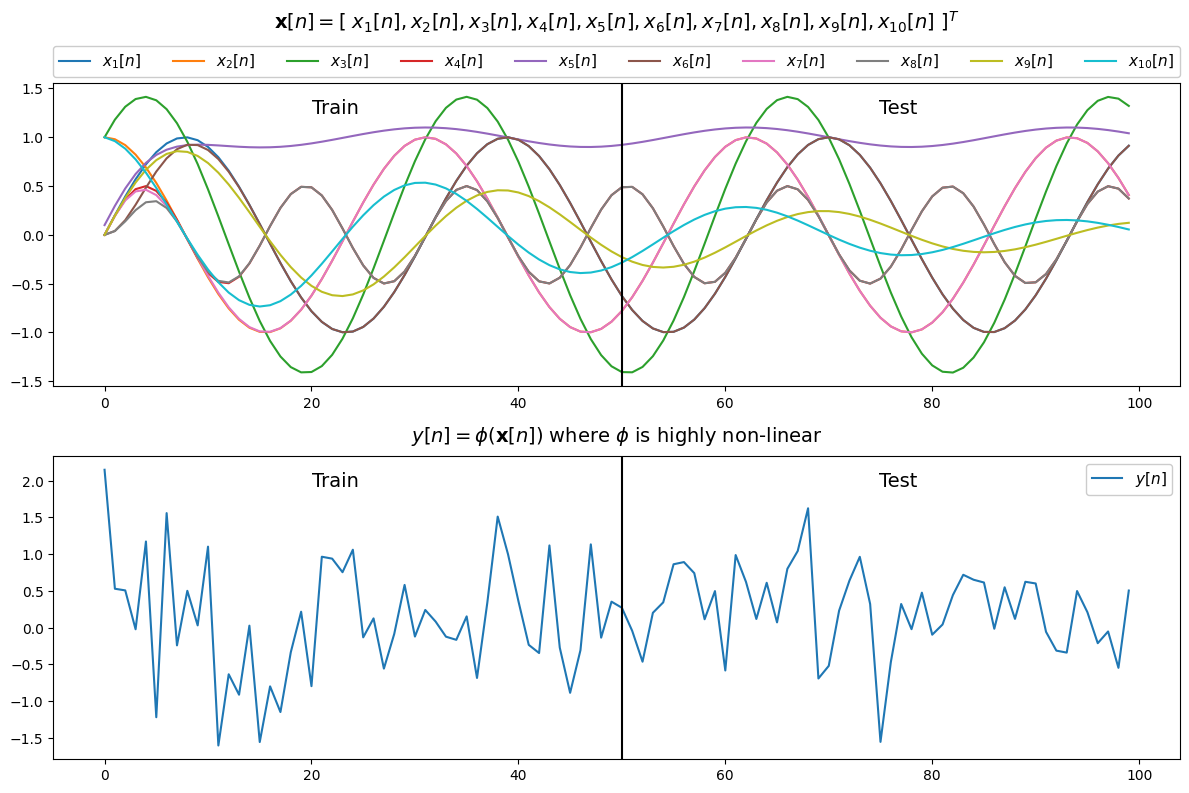

In [6]:
plot_data(X, y)

In [7]:
models = [LMS(), nonlinear_LMS(), deep_network(deep_network_layers)]

loss = train_models(X, y, models, epochs, learning_rate)

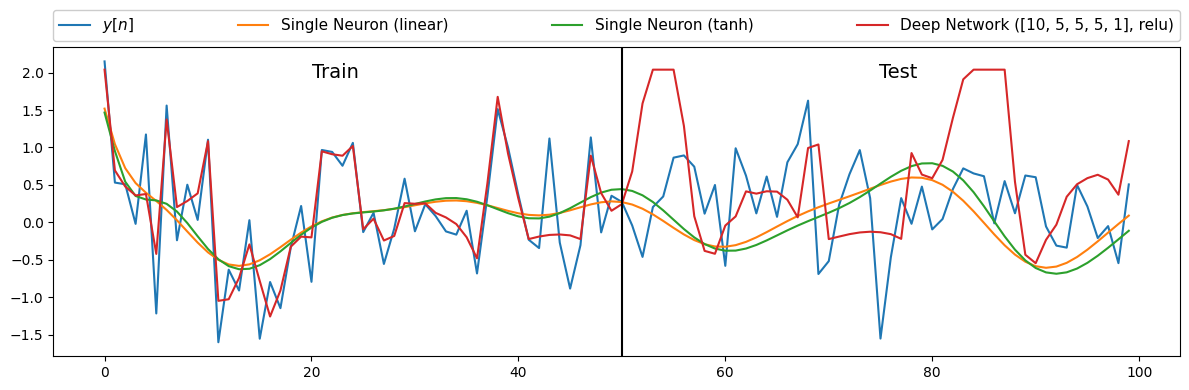

In [8]:
plot_output(X, y, models, deep_network_layers)

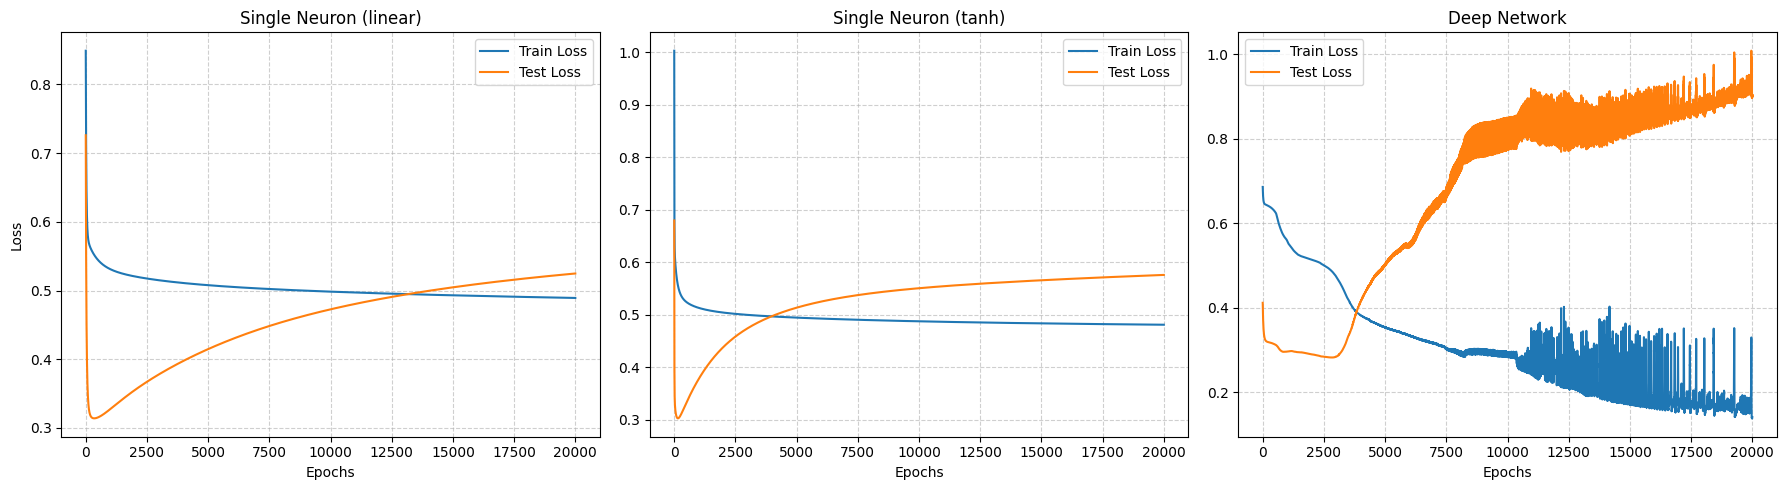

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Single Neuron (linear)', 'Single Neuron (tanh)', 'Deep Network']

for i in range(3):
    train_loss = [x.item() if hasattr(x, 'item') else x for x in loss[i][0]]
    test_loss  = [x.item() if hasattr(x, 'item') else x for x in loss[i][1]]

    axes[i].plot(train_loss, label='Train Loss', color='tab:blue')
    axes[i].plot(test_loss, label='Test Loss', color='tab:orange')
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel('Epochs', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

axes[0].set_ylabel('Loss', fontsize=10)
plt.tight_layout()
plt.show()